# 03 — Modeling

Train and evaluate three classifiers to predict NBA game winners.

| Model | Purpose |
|---|---|
| **Logistic Regression** | Interpretable baseline — coefficients show which stats matter most |
| **Random Forest** | Handles non-linear relationships between features |
| **XGBoost** | Gradient boosted trees — powerful on tabular sports data |

**Train/test split:** first 80% of games (by date) to train, last 20% to test.
This mirrors real-world use — you only predict future games from past data.

**Input:** `data/cleaned/matchups_features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from xgboost import XGBClassifier

matchups = pd.read_csv('../data/cleaned/matchups_features.csv', parse_dates=['GAME_DATE'])
DIFF_FEATURES = [c for c in matchups.columns if c.startswith('DIFF_')]

print(f'Loaded {len(matchups)} matchups | {len(DIFF_FEATURES)} features')
print(f'Home win rate: {matchups["home_win"].mean():.1%}')

Loaded 3638 matchups | 24 features
Home win rate: 55.7%


In [3]:
# Time-based train/test split
df_s = matchups.sort_values('GAME_DATE').reset_index(drop=True)
split_idx = int(len(df_s) * 0.80)
train, test = df_s.iloc[:split_idx], df_s.iloc[split_idx:]

X_train, y_train = train[DIFF_FEATURES], train['home_win']
X_test,  y_test  = test[DIFF_FEATURES],  test['home_win']

print(f'Train: {len(train)} games  ({train["GAME_DATE"].min().date()} to {train["GAME_DATE"].max().date()})')
print(f'Test:  {len(test)} games   ({test["GAME_DATE"].min().date()} to {test["GAME_DATE"].max().date()})')

Train: 2910 games  (2022-10-21 to 2025-01-03)
Test:  728 games   (2025-01-03 to 2025-04-13)


In [5]:
# Train all three models
scaler = StandardScaler()
Xtr_s, Xte_s = scaler.fit_transform(X_train), scaler.transform(X_test)

model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=42),
}

results = {}
print('Training...\n')
for name, model in model_defs.items():
    Xtr = Xtr_s if name == 'Logistic Regression' else X_train
    Xte = Xte_s if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    acc, auc = accuracy_score(y_test, preds), roc_auc_score(y_test, proba)
    results[name] = dict(model=model, preds=preds, proba=proba, accuracy=acc, roc_auc=auc)
    print(f'  {name:25s}  Accuracy={acc:.1%}  ROC-AUC={auc:.3f}')

Training...

  Logistic Regression        Accuracy=65.4%  ROC-AUC=0.709
  Random Forest              Accuracy=65.8%  ROC-AUC=0.702
  XGBoost                    Accuracy=62.6%  ROC-AUC=0.668


In [7]:
# Classification reports
for name, res in results.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, res['preds'], target_names=['Away Win','Home Win'], digits=3))


--- Logistic Regression ---
              precision    recall  f1-score   support

    Away Win      0.684     0.469     0.556       337
    Home Win      0.640     0.813     0.716       391

    accuracy                          0.654       728
   macro avg      0.662     0.641     0.636       728
weighted avg      0.660     0.654     0.642       728


--- Random Forest ---
              precision    recall  f1-score   support

    Away Win      0.695     0.466     0.558       337
    Home Win      0.641     0.824     0.721       391

    accuracy                          0.658       728
   macro avg      0.668     0.645     0.639       728
weighted avg      0.666     0.658     0.646       728


--- XGBoost ---
              precision    recall  f1-score   support

    Away Win      0.621     0.496     0.551       337
    Home Win      0.630     0.739     0.680       391

    accuracy                          0.626       728
   macro avg      0.625     0.617     0.616       728
weigh

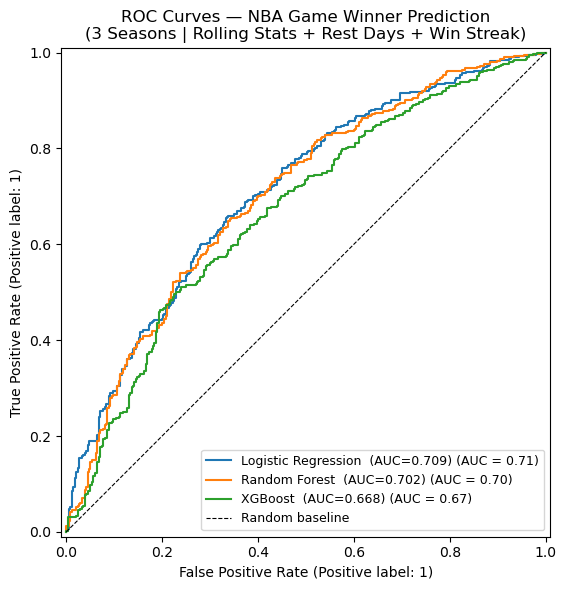

In [9]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['proba'],
        name=f"{name}  (AUC={res['roc_auc']:.3f})", ax=ax)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random baseline')
ax.set_title('ROC Curves — NBA Game Winner Prediction\n(3 Seasons | Rolling Stats + Rest Days + Win Streak)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

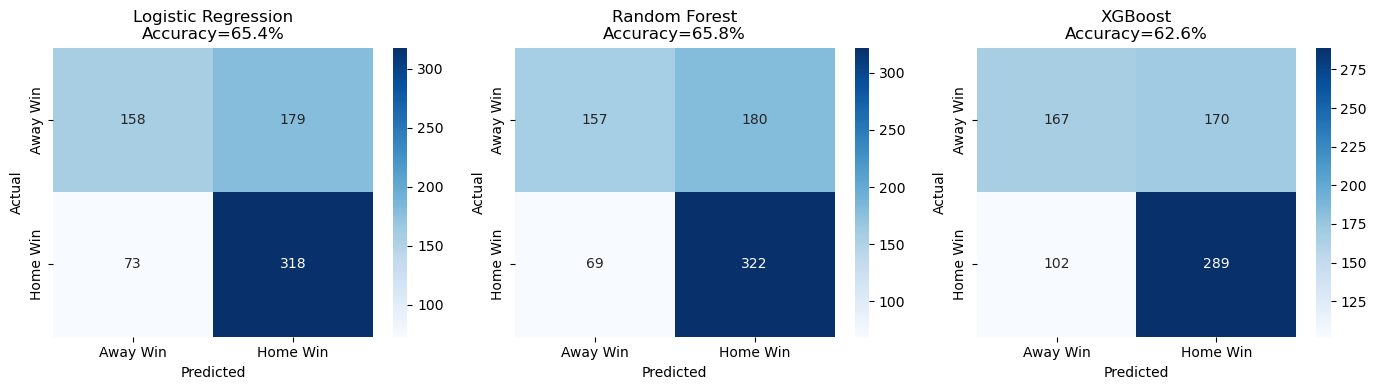

In [11]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Away Win','Home Win'], yticklabels=['Away Win','Home Win'])
    ax.set_title(f"{name}\nAccuracy={res['accuracy']:.1%}")
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

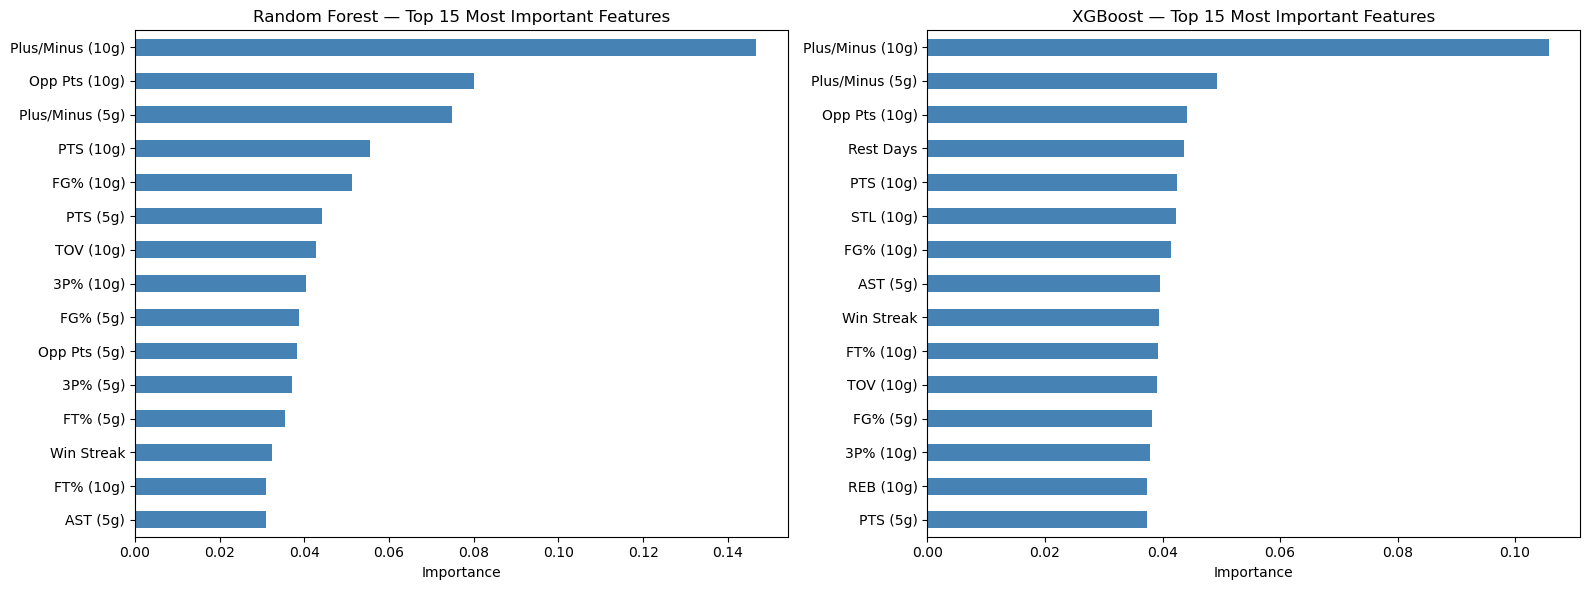

In [15]:
# Feature Importance — Random Forest & XGBoost
clean = lambda s: s.replace('DIFF_','').replace('_ROLL5',' (5g)').replace('_ROLL10',' (10g)')\
    .replace('OPP_PTS','Opp Pts').replace('PLUS_MINUS','Plus/Minus')\
    .replace('REST_DAYS','Rest Days').replace('WIN_STREAK','Win Streak')\
    .replace('FG_PCT','FG%').replace('FG3_PCT','3P%').replace('FT_PCT','FT%').replace('_',' ')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mname in zip(axes, ['Random Forest','XGBoost']):
    imp = pd.Series(results[mname]['model'].feature_importances_, index=DIFF_FEATURES)
    top = imp.sort_values(ascending=True).tail(15)
    top.index = [clean(i) for i in top.index]
    top.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{mname} — Top 15 Most Important Features')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

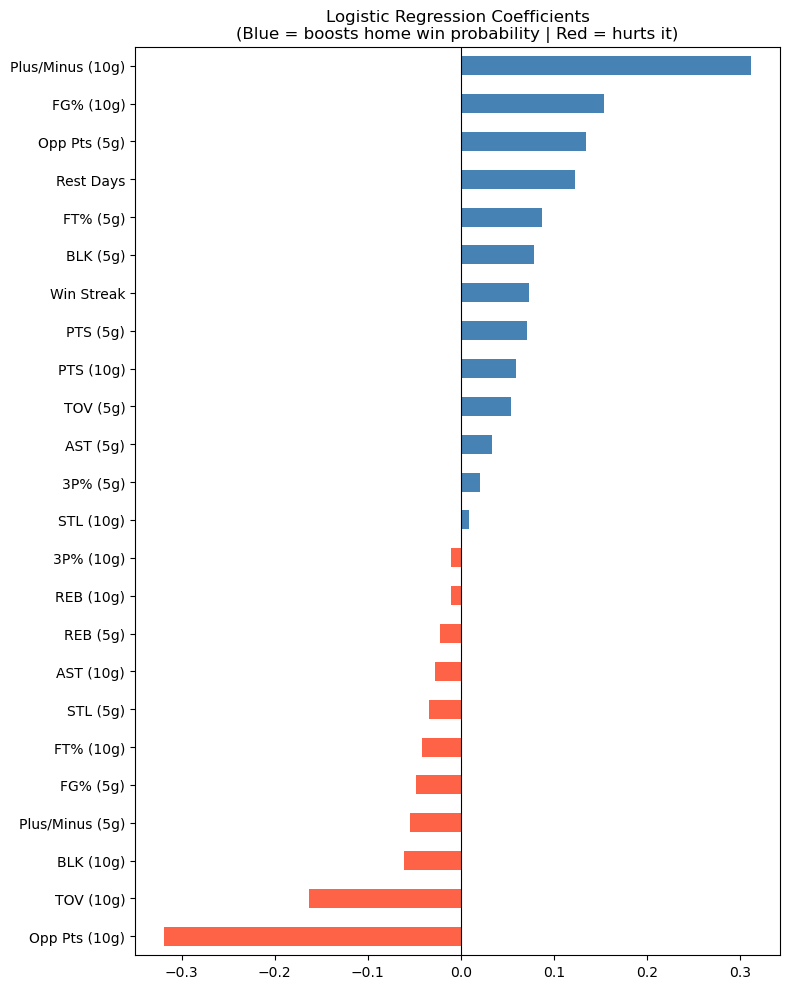

In [17]:
# Logistic Regression Coefficients
lr = results['Logistic Regression']['model']
coef = pd.Series(lr.coef_[0], index=DIFF_FEATURES).sort_values()
coef.index = [clean(i) for i in coef.index]

plt.figure(figsize=(8, 10))
coef.plot(kind='barh', color=['tomato' if v<0 else 'steelblue' for v in coef])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Blue = boosts home win probability | Red = hurts it)')
plt.tight_layout()
plt.show()